# Train GNN Model
Notebook huấn luyện mô hình Graph Neural Network (GNN) cho bài toán phân loại tích phân.

In [33]:
import os
import sys
import pandas as pd
import numpy as np  
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

_NOTEBOOK_DIR = os.path.abspath(os.getcwd())
if os.path.basename(_NOTEBOOK_DIR) == 'model':
    _ROOT = os.path.abspath(os.path.join(_NOTEBOOK_DIR, '..', '..'))
elif os.path.basename(_NOTEBOOK_DIR) == 'ai':
    _ROOT = os.path.abspath(os.path.join(_NOTEBOOK_DIR, '..'))
else:
    _ROOT = _NOTEBOOK_DIR
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

from ai.utils.integral import Integral


In [34]:
# 1. Định nghĩa từ điển cho các loại Node
NODE_TYPE_MAP = {
    'VarExprNode': 0,
    'ConstExprNode': 1,
    'AddExprNode': 2,
    'SubExprNode': 3,
    'MulExprNode': 4,
    'FracExprNode': 5,
    'PowerExprNode': 6,
    'MonoExprNode': 7,
    'SqrtExprNode': 8,
    'SinExprNode': 9,
    'CosExprNode': 10,
    'TanExprNode': 11,
    'ExpExprNode': 12,
    'LogExprNode': 13,
}

NUM_NODE_FEATURES = len(NODE_TYPE_MAP)
print(f"Số loại node: {NUM_NODE_FEATURES}")



Số loại node: 14


In [35]:
def expr_to_graph(latex_str, label):
    try:
        parsed = Integral(latex_str)
        body = parsed.integrand
        if body is None:
            return None
    except Exception:
        return None

    node_features = []
    edges = []

    def traverse(curr_node, current_id):
        node_type = type(curr_node).__name__
        feature = [0.0] * NUM_NODE_FEATURES
        if node_type in NODE_TYPE_MAP:
            feature[NODE_TYPE_MAP[node_type]] = 1.0
        node_features.append(feature)

        if hasattr(curr_node, 'left') and curr_node.left is not None:
            left_id = len(node_features)
            edges.append([current_id, left_id])
            edges.append([left_id, current_id])
            traverse(curr_node.left, left_id)

        if hasattr(curr_node, 'right') and curr_node.right is not None:
            right_id = len(node_features)
            edges.append([current_id, right_id])
            edges.append([right_id, current_id])
            traverse(curr_node.right, right_id)

    traverse(body, 0)

    x = torch.tensor(node_features, dtype=torch.float)
    
    if len(edges) > 0:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    y = torch.tensor(label, dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

In [36]:
class IntegralGNN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(IntegralGNN, self).__init__()
        self.conv1 = SAGEConv(num_features, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, hidden_channels)
        self.fc = Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Message Passing
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)

        x = F.dropout(x, p=0.5, training=self.training)
        x = self.fc(x)
        return x

print("Đã định nghĩa mô hình IntegralGNN.")

Đã định nghĩa mô hình IntegralGNN.


In [37]:
print("Đang đọc dữ liệu từ dataset...")
df = pd.read_csv(os.path.join(_ROOT, "ai", "data", "processed", "dataset.csv"))
df['action'] = pd.to_numeric(df['action'], errors='coerce')
df = df.dropna(subset=['action'])
df['action'] = df['action'].astype(int)

unique_actions = sorted(df['action'].unique())
label_to_index = {action: idx for idx, action in enumerate(unique_actions)}
num_classes = len(label_to_index)
print(f"Số lớp (actions): {num_classes}")
print(f"Tổng số mẫu: {len(df)}")

if num_classes == 0:
    raise ValueError("Không tìm thấy nhãn hợp lệ trong dataset.")

Đang đọc dữ liệu từ dataset...
Số lớp (actions): 5
Tổng số mẫu: 2828


In [ ]:
graph_dataset = []
invalid_count = 0
for _, row in df.iterrows():,
    latex = row['integrand']
    raw_label = int(row['action'])
    label = label_to_index[raw_label]
    data = expr_to_graph(latex, label)
    if data is not None:
        graph_dataset.append(data)
    else:
        invalid_count += 1

print(f"Tổng số mẫu đồ thị hợp lệ: {len(graph_dataset)}, không hợp lệ: {invalid_count}")

if len(graph_dataset) == 0:
    raise ValueError("Không có dữ liệu đồ thị hợp lệ để huấn luyện.")

Tổng số mẫu đồ thị hợp lệ: 2690, không hợp lệ: 138


In [39]:
train_data, test_data = train_test_split(graph_dataset, test_size=0.2, random_state=42)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train: {len(train_data)} mẫu, Test: {len(test_data)} mẫu")

Train: 2152 mẫu, Test: 538 mẫu


In [40]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Sử dụng thiết bị huấn luyện: {device}")

model = IntegralGNN(num_features=NUM_NODE_FEATURES, hidden_channels=64, num_classes=num_classes).to(device)


labels = [data.y.item() for data in train_data]
unique_train_labels = np.unique(labels)
if len(unique_train_labels) == num_classes and num_classes > 1:
    class_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=labels)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
    print("Dùng class weights để cân bằng dữ liệu.")
else:
    criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
print("Khởi tạo mô hình thành công!")

Sử dụng thiết bị huấn luyện: cpu
Dùng class weights để cân bằng dữ liệu.
Khởi tạo mô hình thành công!


In [41]:
for epoch in range(1, 201):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    
    train_loss = total_loss / len(train_loader.dataset)

    # Đánh giá trên tập test
    model.eval()
    correct = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)
            
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())
            
            correct += int((pred == data.y).sum())
    
    test_acc = correct / len(test_loader.dataset)
    test_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1-Macro: {test_f1:.4f}')

print("\nHuấn luyện hoàn thành!")

Epoch: 010, Loss: 0.3852, Test Acc: 0.8773, Test F1-Macro: 0.8785
Epoch: 020, Loss: 0.2010, Test Acc: 0.9535, Test F1-Macro: 0.9581
Epoch: 030, Loss: 0.1499, Test Acc: 0.9517, Test F1-Macro: 0.9557
Epoch: 040, Loss: 0.1390, Test Acc: 0.9535, Test F1-Macro: 0.9576
Epoch: 050, Loss: 0.1011, Test Acc: 0.9554, Test F1-Macro: 0.9591
Epoch: 060, Loss: 0.1121, Test Acc: 0.9591, Test F1-Macro: 0.9629
Epoch: 070, Loss: 0.0830, Test Acc: 0.9628, Test F1-Macro: 0.9657
Epoch: 080, Loss: 0.0822, Test Acc: 0.9628, Test F1-Macro: 0.9657
Epoch: 090, Loss: 0.0773, Test Acc: 0.9591, Test F1-Macro: 0.9624
Epoch: 100, Loss: 0.0704, Test Acc: 0.9591, Test F1-Macro: 0.9615
Epoch: 110, Loss: 0.0641, Test Acc: 0.9647, Test F1-Macro: 0.9672
Epoch: 120, Loss: 0.0803, Test Acc: 0.9628, Test F1-Macro: 0.9666
Epoch: 130, Loss: 0.0724, Test Acc: 0.9647, Test F1-Macro: 0.9667
Epoch: 140, Loss: 0.0726, Test Acc: 0.9665, Test F1-Macro: 0.9684
Epoch: 150, Loss: 0.0657, Test Acc: 0.9665, Test F1-Macro: 0.9689
Epoch: 160

In [42]:
_SAVED = os.path.join(_ROOT, "ai", "saved_models")
os.makedirs(_SAVED, exist_ok=True)
model_path = os.path.join(_SAVED, "best_gnn_model.pth")
torch.save(model.state_dict(), model_path)
print(f"\n✅ Đã lưu mô hình GNN tốt nhất")


✅ Đã lưu mô hình GNN tốt nhất


In [43]:
# 11. Đánh giá mô hình GNN - Biểu diễn thông số mô hình
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 50)
print("          THÔNG SỐ MÔ HÌNH INTEGRALGNN")
print("=" * 50)
print(f"Tổng số tham số (Total parameters):      {total_params:,}")
print(f"Tham số huấn luyện (Trainable params):    {trainable_params:,}")
print("-" * 50)
print("Chi tiết các lớp mạng (Layer Details):")
for name, param in model.named_parameters():
    print(f"  - {name:<12}: shape={list(param.shape):<18} | numel={param.numel():,}")
print("=" * 50)

          THÔNG SỐ MÔ HÌNH INTEGRALGNN
Tổng số tham số (Total parameters):      18,693
Tham số huấn luyện (Trainable params):    18,693
--------------------------------------------------
Chi tiết các lớp mạng (Layer Details):


TypeError: unsupported format string passed to list.__format__

BÁO CÁO CHI TIẾT HIỆU NĂNG PHÂN LOẠI (Classification Report):
                        precision    recall  f1-score   support

        0: Rút hằng số       1.00      0.96      0.98        90
     1: Tách tổng/hiệu       0.94      1.00      0.97        87
2: Công thức đặc trưng       0.93      0.99      0.96       138
    3: Đổi biến u=ax+b       1.00      0.92      0.96       145
4: Tích phân từng phần       0.99      1.00      0.99        78

              accuracy                           0.97       538
             macro avg       0.97      0.97      0.97       538
          weighted avg       0.97      0.97      0.97       538



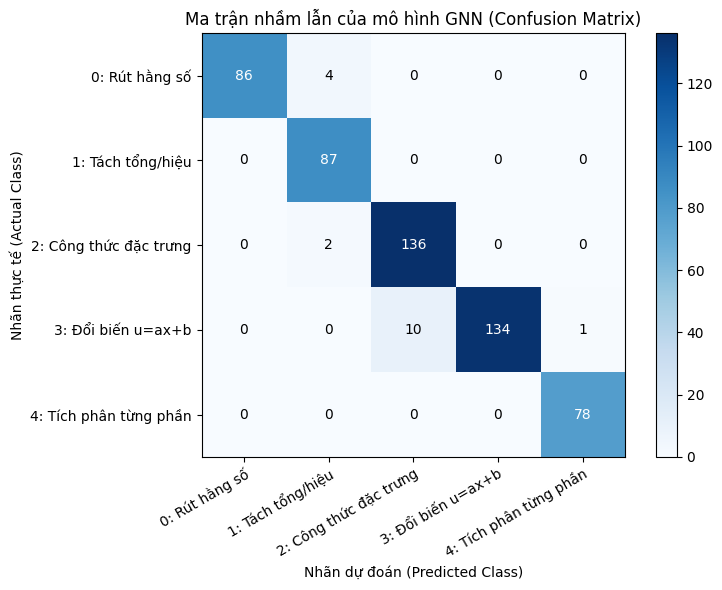

In [ ]:
# 12. Đánh giá mô hình GNN - Ma trận nhầm lẫn (Confusion Matrix)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data)
        pred = out.argmax(dim=1)
        y_true.extend(data.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

action_names = [
    "0: Rút hằng số",
    "1: Tách tổng/hiệu",
    "2: Công thức đặc trưng",
    "3: Đổi biến u=ax+b",
    "4: Tích phân từng phần"
]

print("BÁO CÁO CHI TIẾT HIỆU NĂNG PHÂN LOẠI (Classification Report):")
print(classification_report(y_true, y_pred, target_names=action_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)

try:
    import seaborn as sns
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        xticklabels=action_names, 
        yticklabels=action_names
    )
    plt.title("Ma trận nhầm lẫn của mô hình GNN (Confusion Matrix)", fontsize=14, pad=15)
    plt.xlabel("Nhãn dự đoán (Predicted Class)", fontsize=12, labelpad=10)
    plt.ylabel("Nhãn thực tế (Actual Class)", fontsize=12, labelpad=10)
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
except ImportError:
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=action_names, yticklabels=action_names,
           title="Ma trận nhầm lẫn của mô hình GNN (Confusion Matrix)",
           ylabel="Nhãn thực tế (Actual Class)",
           xlabel="Nhãn dự đoán (Predicted Class)")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    plt.show()